In [ ]:
#importing the pandas library to read the csv file
import pandas as pd

df = pd.read_csv('Data/Rawdata.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:
#removing the columns that are not needed for the analysis
df.drop('customerID', axis=1, inplace=True)

In [37]:
#checking the data types of the columns
print(df.dtypes)

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [38]:
#handling dataype issues
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [39]:
#checking missing values
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [40]:
#handling missing values in the 'TotalCharges' column by converting it to numeric and filling missing values with the median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [41]:
#handling outliers (IQR method)
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['MonthlyCharges'] >= lower) & (df['MonthlyCharges'] <= upper)]

In [43]:
#label encoding for binary categorical variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [54]:
#one hot encoding for multi-class categorical
multi_class_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

In [47]:
#future engineering
# Avoid division by zero
df['avgmonthlyspend'] = df['TotalCharges'] / (df['tenure'] + 1)

In [ ]:
#service count 
service_cols = [col for col in df.columns if any(x in col for x in [
    'onlinesecurity', 'onlinebackup', 'deviceprotection',
    'techsupport', 'streamingtv', 'streamingmovies'
])]

df['servicecount'] = df[service_cols].sum(axis=1)

"New features were created to capture customer behavior and improve model performance.”

In [ ]:
#removing the original columns that were used to create the new features
df = pd.get_dummies(df, drop_first=True)

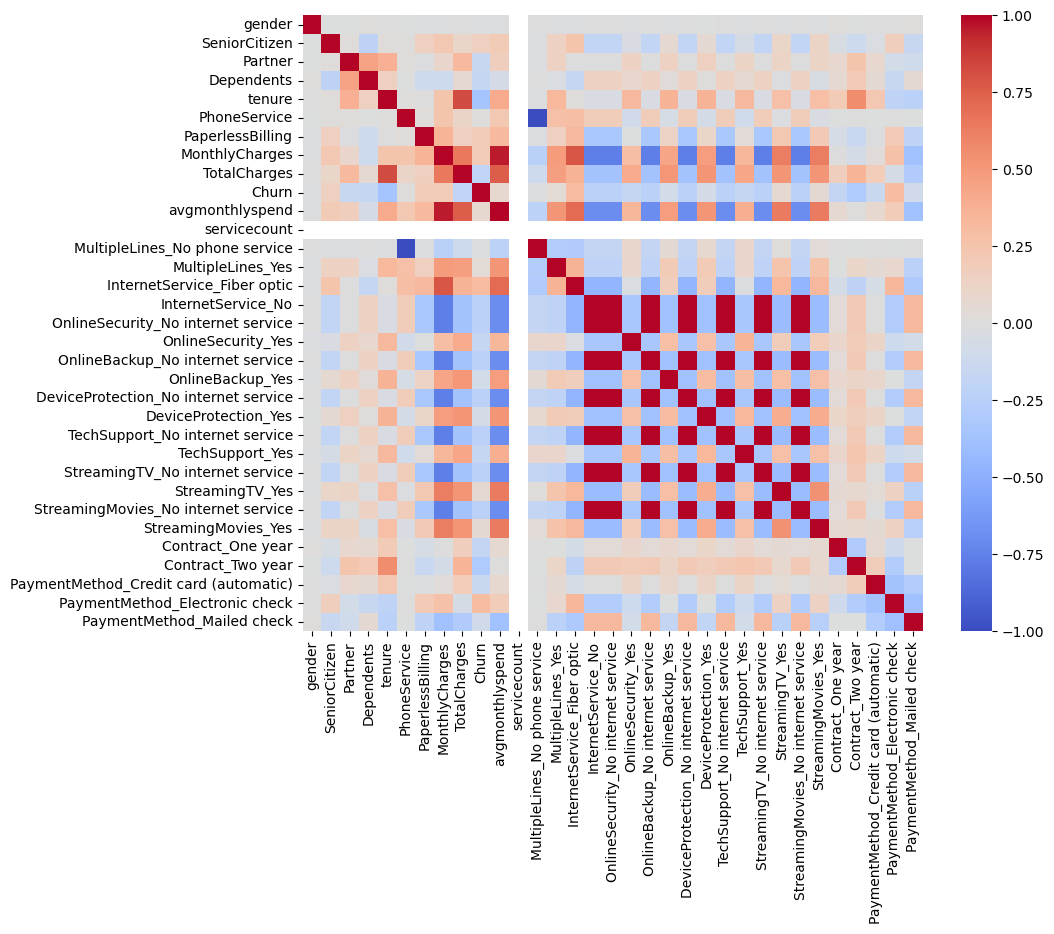

In [57]:
#Feature selection using correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()


In [ ]:
#removing the 'TotalCharges' column as it has a high correlation with 'avgmonthlyspend' and can cause multicollinearity issues
df.drop(['TotalCharges'], axis=1, inplace=True)

In [ ]:
#Feature importance using Random Forest
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Churn', axis=1)
y = df['Churn']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(15))

tenure                            0.192853
avgmonthlyspend                   0.177967
MonthlyCharges                    0.168567
InternetService_Fiber optic       0.040197
Contract_Two year                 0.039518
PaymentMethod_Electronic check    0.036428
gender                            0.027705
PaperlessBilling                  0.025723
Contract_One year                 0.025281
OnlineSecurity_Yes                0.024569
Partner                           0.024116
TechSupport_Yes                   0.023277
OnlineBackup_Yes                  0.021276
SeniorCitizen                     0.020583
DeviceProtection_Yes              0.018998
dtype: float64


In [ ]:
#selecting the top 15 features based on feature importance
top_features = importance.head(15).index

df = df[top_features.tolist() + ['Churn']]

In [ ]:
#checking for missing values and data types after preprocessing
print(df.isnull().sum())
print(df.dtypes)

tenure                             0
avgmonthlyspend                   11
MonthlyCharges                     0
InternetService_Fiber optic        0
Contract_Two year                  0
PaymentMethod_Electronic check     0
gender                             0
PaperlessBilling                   0
Contract_One year                  0
OnlineSecurity_Yes                 0
Partner                            0
TechSupport_Yes                    0
OnlineBackup_Yes                   0
SeniorCitizen                      0
DeviceProtection_Yes               0
Churn                              0
dtype: int64
tenure                              int64
avgmonthlyspend                   float64
MonthlyCharges                    float64
InternetService_Fiber optic          bool
Contract_Two year                    bool
PaymentMethod_Electronic check       bool
gender                              int64
PaperlessBilling                    int64
Contract_One year                    bool
OnlineSecurity_Ye

In [ ]:
#handling any remaining missing values in the 'avgmonthlyspend' column by filling them with the median
import numpy as np

# Replace inf with NaN (safety)
df['avgmonthlyspend'].replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values
df['avgmonthlyspend'].fillna(df['avgmonthlyspend'].median(), inplace=True)

C:\Users\VIDYA\AppData\Local\Temp\ipykernel_18132\3775543486.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['avgmonthlyspend'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\VIDYA\AppData\Local\Temp\ipykernel_18132\3775543486.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['avgmonthlyspend'].replace([np.inf, -np.inf],

In [ ]:
#converting boolean columns to integers
bool_cols = df.select_dtypes(include=['bool']).columns

df[bool_cols] = df[bool_cols].astype(int)

C:\Users\VIDYA\AppData\Local\Temp\ipykernel_18132\1733541749.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[bool_cols] = df[bool_cols].astype(int)


In [ ]:
#checking for missing values and data types after preprocessing
print(df.isnull().sum())
print(df.dtypes)

tenure                            0
avgmonthlyspend                   0
MonthlyCharges                    0
InternetService_Fiber optic       0
Contract_Two year                 0
PaymentMethod_Electronic check    0
gender                            0
PaperlessBilling                  0
Contract_One year                 0
OnlineSecurity_Yes                0
Partner                           0
TechSupport_Yes                   0
OnlineBackup_Yes                  0
SeniorCitizen                     0
DeviceProtection_Yes              0
Churn                             0
dtype: int64
tenure                              int64
avgmonthlyspend                   float64
MonthlyCharges                    float64
InternetService_Fiber optic         int64
Contract_Two year                   int64
PaymentMethod_Electronic check      int64
gender                              int64
PaperlessBilling                    int64
Contract_One year                   int64
OnlineSecurity_Yes               

The dataset was cleaned and transformed to make it suitable for machine learning models. Irrelevant features such as customerID were removed, and column names were standardized for consistency. Data types were corrected by converting TotalCharges to numeric format, and missing values were handled using median imputation.

Categorical variables were encoded using One-Hot Encoding to convert them into numerical form. New features such as AvgMonthlySpend and ServiceCount were created to capture customer behavior more effectively. Issues like division by zero and missing values in derived features were handled appropriately.

Correlation analysis was performed to identify redundant features, and highly correlated features like TotalCharges were removed. Feature selection was further refined using Random Forest feature importance. Finally, all boolean values were converted to numeric format, and the dataset was validated to ensure there were no missing values and all features were numeric.

The processed dataset is now clean, consistent, and ready for model training.

In [ ]:
#saving the preprocessed data to a new csv file
import os
os.getcwd()

'c:\\Users\\VIDYA\\Desktop\\teleconnect-ml-assignment'

In [74]:
import os

os.makedirs('data/processed', exist_ok=True)

In [75]:
df.to_csv('data/processed/processed_data.csv', index=False)

In [76]:
os.listdir('data/processed')

['processed_data.csv']